In [1]:
!pip install -q ruptures 
!pip install -q scikit-learn==1.1.3
!pip install -q stochastic

# Generalization of Ensemble-Based Correction


The correction of exponent α estimates can also be performed for cases where they are obtained not through TA-MSD, but by any method, including both classical statistical methods and modern machine learning methods, such as neural networks. It is important to have empirical information about the dependence of the variance of α estimates σ ̂_method^2 on trajectory length T, as well as the ensemble mean value that can be obtained by various methods. Such information allows correction of predictions from any α estimation methods, based on knowledge of the error structure arising from limited trajectory length.
We propose the following numerical approach. For a set of fixed values of α and various values of trajectory length T from the range of interest, an ensemble of trajectories is generated (e.g., several thousand for each pair {α, T}). After estimating α for each trajectory from the ensemble and obtaining estimates α ̂, the sample variance of estimates σ_total^2 [α ̂ ] corresponding to the given pair of values {α, T} is calculated. Since all generated trajectories in the ensemble have the same specified α value, σ_α^2=0, and therefore σ ̂_method^2= σ ̂_total^2. This allows obtaining the dependence of empirical values σ ̂_method^2 on T.
Then, for each fixed value of α, linear regression is performed on the dependence of estimate variance σ ̂_method^2 on the variable 1/T, with the goal of identifying patterns of variance change with increasing trajectory length. Having obtained a family of such dependencies for various α, an approximating function can be constructed that, given T and estimate α ̂_TEAMSD, allows interpolation to calculate the expected value of estimate variance σ ̂_method^2.
Correction of estimates obtained by a specific method, for which we now have a function that provides σ ̂_method^2 from T and α ̂_TEAMSD, is performed using formula, with the only difference being that σ ̂_corrected is calculated using the following modification of formula:
σ ̂_corrected=√(σ ̂_total^2-σ_method^2  )	
Thus, we correct the estimates of anomaly exponents for each trajectory obtained by a specific method.
Appendix B provides examples of determining anomalous diffusion parameters for TA-MSD, Whittle, and CINNAMON methods (based on machine learning and independent of trajectory length), illustrating that the dependence of alpha variance on 1/T can be approximated by linear regression.



In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import sys
sys.path.append('/kaggle/input/cinnamon/andi_challenge_2_wust-main')

In [4]:
import os
os.chdir('/kaggle/input/cinnamon/andi_challenge_2_wust-main')

In [5]:
import sys
import joblib
import os
import model
from input_utils import get_fovs_of_experiment
from common import State
from ensemble import naive_aggregation, simple_aggregation
from segmentation import analyze_fov, MultiEstimCost, mw_rupture_cp_detection, simple_state_classifier
from estimators import estimate_with_noise_1, estimate_with_noise_3
from _03_characteristics import get_characteristics_new
from submission_utils import create_submission
from cp_detector import CPDetector
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from multiprocessing import Pool
import src.deep.tf_dain
THRASHOLD = 0.1
__TRACK_2_PATH = '/kaggle/input/andi2-benchmark-dataset/track_2'
__GRADIENT_BOOSTING_PATH = "/kaggle/input/cinnamon/andi_challenge_2_wust-main/model_alpha_boost_big"

gradient_boosting = joblib.load(__GRADIENT_BOOSTING_PATH)
def alpha_estim_boost(x):
    return gradient_boosting.predict(get_characteristics_new(x).fillna(0))[0]

In [6]:
import numpy as np

class Tamsd:
    def __init__(self, use_correction=False, trim_percent=0, is_increments=False, return_TEA=False):
        """
        Ініціалізація класу Tamsd.
        Args:
            use_correction (bool): Чи застосовувати корекцію TEA-MSD&variance. За замовчуванням False.
            trim_percent (int): Відсоток найбільших значень для обрізання. За замовчуванням 0.
            is_increments (bool): Чи дані є інкрементами. Якщо False, дані є позиціями (кумулятивними рядами).
            return_TEA (bool): Чи повертати TEA exponent замість batch exponents.
        """
        self.use_correction = use_correction
        self.trim_percent = trim_percent
        self.is_increments = is_increments
        self.return_TEA = return_TEA

    @staticmethod
    def trim_array1s(arr, percent):
        """
        Видаляє заданий відсоток найбільших значень з кожного рядка 2D масиву, ігноруючи NaN.
        
        Args:
            arr (np.ndarray): Вхідний 2D масив.
            percent (float): Відсоток значень для видалення (0 <= percent < 100).
        Returns:
            np.ndarray: Масив зі значеннями вище порогу, заміненими на NaN.
        """
        if percent == 0:
            return arr
        
        result = arr.copy()
        for i in range(arr.shape[0]):
            row = arr[i]
            valid_mask = ~np.isnan(row)
            valid_values = row[valid_mask]
            
            if len(valid_values) == 0:
                continue
            
            k = int(np.round(len(valid_values) * (percent / 100.0)))
            
            if k > 0:
                # Сортуємо валідні значення і знаходимо поріг
                sorted_valid = np.sort(valid_values)
                threshold = sorted_valid[-k]
                # Замінюємо значення вище порогу на NaN
                result[i] = np.where(row < threshold, row, np.nan)
        
        return result

    @staticmethod
    def trim_array1s_tea(arr, percent):
        """
        Видаляє заданий відсоток найбільших значень з усього масиву, ігноруючи NaN.
        Кількість елементів для видалення базується на всіх не-NaN значеннях.
        Args:
            arr (np.ndarray): Вхідний масив.
            percent (float): Відсоток значень для видалення (0 <= percent < 100).
        Returns:
            np.ndarray: Масив зі значеннями вище порогу, заміненими на NaN.
        """
        if percent == 0:
            return arr
        
        valid_mask = ~np.isnan(arr)
        valid_values = arr[valid_mask]
        
        if len(valid_values) == 0:
            return arr
        
        k = int(np.round(len(valid_values) * (percent / 100.0)))
        
        if k == 0:
            return arr
        
        # Сортуємо валідні значення і знаходимо поріг
        sorted_valid = np.sort(valid_values)
        threshold = sorted_valid[-k]
        # Замінюємо значення вище порогу на NaN
        result = np.where(arr < threshold, arr, np.nan)
        
        return result

    def normalize_distribution(self, arr, target_mean, T):
        """
        Нормалізація розподілу з корекцією.
        Args:
            arr (np.ndarray): Вхідний масив.
            target_mean (float): Цільове середнє значення.
            T (float): Ефективний час/індикатор кількості.
        Returns:
            np.ndarray: Нормалізований масив.
        """
        current_mean = np.nanmean(arr)
        current_std = np.nanstd(arr)
        adjustment_term = np.maximum(current_std**2 - 0.92 / T, 0)**0.5
        standardized = (arr - current_mean) / (current_std + 1e-8)
        return standardized * adjustment_term + target_mean

    def __call__(self, inputs):
        """
        Обчислення альфа (показника Херста).
        Args:
            inputs (np.ndarray): Вхідний масив форми (batch_size, timesteps, input_channels).
                                 Якщо is_increments=False, це позиції (кумулятивні ряди).
                                 Якщо is_increments=True, це інкременти.
        Returns:
            np.ndarray: Оцінені значення H (показник Херста).
        """
        # Визначаємо, працюємо з позиціями чи інкрементами
        if self.is_increments:
            # Якщо дані є інкрементами, перетворюємо їх на позиції (кумулятивні суми)
            # Припускаємо, що початкова позиція = 0
            positions = np.concatenate([np.zeros((inputs.shape[0], 1, inputs.shape[2])), 
                                       np.cumsum(inputs, axis=1)], axis=1)
        else:
            # Дані вже є позиціями
            positions = inputs
        
        batch_size = positions.shape[0]
        timesteps = positions.shape[1]
        input_channels = positions.shape[2]

        # Підрахунок не-NaN елементів
        not_nan_mask = ~np.isnan(positions)
        not_nan_count = np.sum(not_nan_mask)

        epsilon = 0
        max_lag = 4
        msds = []
        teamsd_list = []

        # --- Обчислення MSD та TEA-MSD ---
        for lag in range(1, max_lag + 1):
            # Обчислюємо квадрати зміщень: (position[t+lag] - position[t])^2
            # Це еквівалентно підходу в реалізації 2
            displacements = positions[:, lag:, :] - positions[:, :-lag, :]
            squared_displacements = np.square(displacements)
            squared_displacements_sum = np.sum(squared_displacements, axis=2)

            # Для MSD – обрізаємо кожен рядок
            msd = np.nanmean(
                self.trim_array1s(squared_displacements_sum, self.trim_percent),
                axis=1
            )
            msds.append(msd)

            # Для TEA-MSD – обрізаємо масив цілком
            teamsd_lag = np.nanmean(
                self.trim_array1s_tea(squared_displacements_sum, self.trim_percent)
            )
            teamsd_list.append(teamsd_lag)

        msds = np.stack(msds, axis=1)  # (batch_size, max_lag)
        teamsd = np.array(teamsd_list)  # (max_lag,)

        t_lags = np.arange(1, max_lag + 1, dtype=np.float32)

        
        if self.return_TEA:

            if not np.any(np.isnan(teamsd)):
                alpha = np.clip(np.polyfit(np.log(t_lags), np.log(teamsd), deg = 1)[0], 0.001, 1.999)
                # print(idx, np.log(row))
            else:
                alpha = np.NaN
                # print('-')
            
    
            # --- Обмеження alpha до валідного діапазону ---
            alpha = np.clip(alpha, 0.0001, 1.999) 
            return alpha   
        
        alpha = np.zeros(batch_size, dtype= float) 
        for idx, row in enumerate(msds):
            if not np.any(np.isnan(row)):
                alpha[idx] = np.clip(np.polyfit(np.log(t_lags), np.log(row), deg = 1)[0], 0.001, 1.999)
                # print(idx, np.log(row))
            else:
                alpha[idx] = np.NaN
                # print('-')
        
        # --- Обмеження alpha до валідного діапазону ---        
        alpha = np.clip(alpha, 0.0001, 1.999) 
        # last_msd = msds[:, -1]  # (batch_size,)
        # mask_nan = last_msd < 1e-6
        # alpha = np.where(mask_nan, np.nan, alpha)
        # alpha = np.where(mask_nan, 1.0, alpha) # використати для уникненн NaN
        # alpha = np.nan_to_num(alpha, nan=1.0) # використати для уникненн NaN
        
        return alpha

## Code to compare results against the Whittle method and the standard TA-MSD method

In [7]:
import matplotlib.pyplot as plt


In [8]:

#  from https://github.com/AnDiChallenge/
import numpy as np
import pandas as pd
from stochastic.processes.noise import FractionalGaussianNoise as FGN
import warnings
import scipy.stats
def gaussian(params:list|int, # If list, mu and sigma^2 of the gaussian. If int, we consider sigma = 0
             size = 1,  # Number of samples to get.
             bound = None # Bound of the Gaussian, if any.
            )-> np.array: # Samples from the given Gaussian distribution
    '''
    Samples from a Gaussian distribution of given parameters.
    '''
    # if we are given a single number, we consider equal to mean and variance = 0
    if isinstance(params, float) or isinstance(params, int):
        if size == 1:
            return params
        else:
            return np.array(params).repeat(size)
    else:
        mean, var = params        
        if bound is None:
            val = np.random.normal(mean, np.sqrt(var), size)
        if bound is not None:
            lower, upper = bound
            if var == 0: 
                if mean > upper or mean < lower:
                    raise ValueError('Demanded value outside of range.')
                val = np.ones(size)*mean
            else:
                val = scipy.stats.truncnorm.rvs((lower-mean)/np.sqrt(var),
                                                (upper-mean)/np.sqrt(var),
                                                loc = mean,
                                                scale = np.sqrt(var),
                                                size = size)
        if size == 1:
            return val[0]
        else:
            return val


In [9]:
# Dataset generration from https://github.com/AnDiChallenge/

# %% ../source_nbs/lib_nbs/models_phenom.ipynb 5
class models_phenom():
    def __init__(self):
        '''
        This class handles the generation of trajectories from different theoretical models. 
        ''' 
        # We define here the bounds of the anomalous exponent and diffusion coefficient
        self.bound_D = [1e-12, 1e6]
        self.bound_alpha = [0, 1.999]
        
        # We also define the value in which we consider directed motion
        self.alpha_directed = 1.9
        
        # Diffusion state labels: the position of each type defines its numerical label
        # i: immobile/trapped; c: confined; f: free-diffusive (normal and anomalous); d: directed
        self.lab_state = ['i', 'c', 'f', 'd']

# %% ../source_nbs/lib_nbs/models_phenom.ipynb 7
class models_phenom(models_phenom):
    
    @staticmethod
    def disp_fbm(alpha : float,
                 D : float,
                 T: int, 
                 deltaT : int = 1):
        ''' Generates normalized Fractional Gaussian noise. This means that, in 
        general:
        $$
        <x^2(t) > = 2Dt^{alpha}
        $$
                            
        and in particular:
        $$
        <x^2(t = 1)> = 2D 
        $$
        
        Parameters
        ----------
        alpha : float in [0,2]
            Anomalous exponent
        D : float
            Diffusion coefficient
        T : int
            Number of displacements to generate
        deltaT : int, optional
            Sampling time
            
        Returns
        -------
        numpy.array
            Array containing T displacements of given parameters
        
        '''
        
        # Generate displacements
        disp = FGN(hurst = alpha/2).sample(n = T)
        # Normalization factor
        disp *= np.sqrt(T)**(alpha)
        # Add D
        disp *= np.sqrt(2*D*deltaT)        
        
        return disp

# %% ../source_nbs/lib_nbs/models_phenom.ipynb 18
class models_phenom(models_phenom):
    
    @staticmethod
    def _constraint_alpha(alpha_1, alpha_2, epsilon_a):
        ''' Defines the metric for constraining the changes in anomalous
        exponent'''
        return alpha_1 - alpha_2 < epsilon_a
    
    @staticmethod
    def _constraint_d(d1, d2, gamma_d):
        ''' Defines the metric for constraining the changes in anomalous
        exponent'''
        if gamma_d < 1:
            return d2 > d1*gamma_d
        if gamma_d > 1:
            return d2 < d1*gamma_d
    
    @staticmethod
    def _sample_diff_parameters(alphas : list, # List containing the parameters to sample anomalous exponent in state (adapt to sampling function)
                                Ds : list, # List containing the parameters to sample the diffusion coefficient in state (adapt to sampling function).
                                num_states : int, # Number of diffusive states.
                                epsilon_a : float, #  Minimum distance between anomalous exponents of various states.
                                gamma_d : float, # Factor between diffusion coefficient of various states.
                               ) : 
        '''    
        Given information of the anomalous exponents (alphas), diffusion coefficients (Ds), the function
        samples these from a bounded Gaussian distribution with the indicated constraints (epsilon_a,
        gamma_d). Outputs the list of demanded alphas and Ds.
        
        
        Parameters
        ----------
        alphas : list
        List containing the parameters to sample anomalous exponent in state (adapt to sampling function).
        Ds : list
        List containing the parameters to sample the diffusion coefficient in state (adapt to sampling function).
        num_states : int
        Number of diffusive states.
        epsilon_a : float
        Minimum distance between anomalous exponents of various states.            
                epsilon workflow: we check val[i] - val[i-1] < epsilon
                    if you want that val[i] > val[i-1]: epsilon has to be positive
                    if you want that val[i] < val[i-1]: epsilon has to be negative
                    if you don't care: epsilon = 0
                
        gamma_d : float
        Factor between diffusion coefficient of various states.            
                gamma workflow: 
                    for gamma < 1: val[i] < val[i-1]*gamma
                    for gamma > 1: val[i] > val[i-1]*gamma
                    for gamma = 1: no check
        Returns
        -------
            :alphas_traj (list): list of anomalous exponents
            :Ds_traj (list): list of diffusion coefficients
                      
        '''

        
        alphas_traj = []
        Ds_traj = []
        for i in range(num_states): 

            # for the first state we just sample normally
            if i == 0:
                alphas_traj.append(float(gaussian(alphas[i], bound = models_phenom().bound_alpha)))
                Ds_traj.append(float(gaussian(Ds[i], bound = models_phenom().bound_D)))
           
            # For next states we take into account epsilon distance between diffusion
            # parameter
            else:
                ## Checking alpha
                alpha_state = float(gaussian(alphas[i], bound = models_phenom().bound_alpha))
                D_state = float(gaussian(Ds[i], bound = models_phenom().bound_D))

                if epsilon_a[i-1] != 0:
                    idx_while = 0
                    while models_phenom()._constraint_alpha(alphas_traj[-1], alpha_state, epsilon_a[i-1]):
                    #alphas_traj[-1] - alpha_state < epsilon_a[i-1]:
                        alpha_state = float(gaussian(alphas[i], bound = models_phenom().bound_alpha))                        
                        idx_while += 1
                        if idx_while > 100: # check that we are not stuck forever in the while loop
                            raise FileNotFoundError(f'Could not find correct alpha for state {i} in 100 steps. State distributions probably too close.')

                alphas_traj.append(alpha_state)
                
                ## Checking D
                if gamma_d[i-1] != 1:    
                    
                    idx_while = 0
                    while models_phenom()._constraint_d(Ds_traj[-1], D_state, gamma_d[i-1]):
                        D_state = float(gaussian(Ds[i], bound = models_phenom().bound_D))
                        idx_while += 1
                        if idx_while > 100: # check that we are not stuck forever in the while loop
                            raise FileNotFoundError(f'Could not find correct D for state {i} in 100 steps. State distributions probably too close.')
               
    
                Ds_traj.append(D_state)
                
        return alphas_traj, Ds_traj

# %% ../source_nbs/lib_nbs/models_phenom.ipynb 26
class models_phenom(models_phenom):
    
    @staticmethod
    def _single_state_traj(T :int = 200, 
                          D : float = 1, 
                          alpha : float = 1, 
                          L : float = None,
                          deltaT : int = 1,
                          dim : int = 2):
        '''
        Generates a single state trajectory with given parameters. 
        
        Parameters
        ----------
        T : int
            Length of the trajectory
        D : float
            Diffusion coefficient       
        alpha : float
            Anomalous exponent
        L : float
            Length of the box acting as the environment
        deltaT : int, optional
            Sampling time
        dim : int
            Dimension of the walk (can be 2 or 3)
            
        Returns
        -------
        tuple
            - pos: position of the particle
            - labels:  anomalous exponent, D and state at each timestep. State is always free here.
            
        '''
        
        
        # Trajectory displacements
        disp_d = []
        for d in range(dim):
            disp_d.append(models_phenom().disp_fbm(alpha, D, T))
        # Labels
        lab_diff_state = np.ones(T)*models_phenom().lab_state.index('f') if alpha < models_phenom().alpha_directed else np.ones(T)*models_phenom().lab_state.index('d')
        labels = np.vstack((np.ones(T)*alpha, 
                            np.ones(T)*D,
                            lab_diff_state
                           )).transpose()

        # If there are no boundaries
        if not L:
            
            pos = np.vstack([np.cumsum(disp)-disp[0] for disp in disp_d]).transpose()
            
            return pos, labels

        # If there are, apply reflecting boundary conditions
        else:
            pos = np.zeros((T, dim))

            # Initialize the particle in a random position of the box
            pos[0, :] = np.random.rand(dim)*L
            for t in range(1, T):
                if dim == 2:
                    pos[t, :] = [pos[t-1, 0]+disp_d[0][t], 
                                 pos[t-1, 1]+disp_d[1][t]]            
                elif dim == 3:
                    pos[t, :] = [pos[t-1, 0]+disp_d[0][t], 
                                 pos[t-1, 1]+disp_d[1][t], 
                                 pos[t-1, 2]+disp_d[2][t]]            


                # Reflecting boundary conditions
                while np.max(pos[t, :])>L or np.min(pos[t, :])< 0: 
                    pos[t, pos[t, :] > L] = pos[t, pos[t, :] > L] - 2*(pos[t, pos[t, :] > L] - L)
                    pos[t, pos[t, :] < 0] = - pos[t, pos[t, :] < 0]

            return pos, labels

# %% ../source_nbs/lib_nbs/models_phenom.ipynb 33
class models_phenom(models_phenom):
    
    
    def single_state(self,
                     N:int = 10,
                     T:int = 200, 
                     Ds:list = [1, 0], 
                     alphas:list = [1, 0], 
                     L:float = None,
                     dim:int = 2):
        '''
        Generates a dataset made of single state trajectories with given parameters.
        
        Parameters
        ----------
        N : int, list
            Number of trajectories in the dataset
        T : int
            Length of the trajectory
        Ds : float
            If list, mean and variance from which to sample the diffusion coefficient. If float, we consider variance = 0.
        alphas : float
            If list, mean and variance from which to sample the anomalous exponent. If float, we consider variance = 0.
        L : float
            Length of the box acting as the environment
        deltaT : int, optional
            Sampling time            
        dim : int
            Dimension of the walk (can be 2 or 3)
            
        Returns
        -------
        tuple
            - positions: position of the N trajectories.
            - labels:  anomalous exponent, D and state at each timestep. State is always free here.         
        '''

        positions = np.zeros((T, N, dim))
        labels = np.zeros((T, N, 3))

        for n in range(N):
            alpha_traj = gaussian(alphas, bound = self.bound_alpha)
            D_traj = gaussian(Ds, bound = self.bound_D)
            # Get trajectory from single traj function
            pos, lab = self._single_state_traj(T = T, 
                                               D = D_traj, 
                                               alpha = alpha_traj, 
                                               L = L,
                                               dim = dim
                                              )        
            positions[:, n, :] = pos
            labels[:, n, :] = lab

        return positions, labels


In [10]:
"""
This module have been implemented to compute an Hurst exponent
Estimator using maximum of likelyhood on the periodogram.
It is not a log regression as in Hest_Welp
the  periodogram is the one given by the scipy library
these functions hab been made according to whittlenew,
wittlefunc and fspecFGN of Matlab Biyu_code
"""
import numpy as np
import scipy.optimize as so
from math import gamma


def whittle(data):
    """This function compute the Hurst exponent of a signal using
    a maximum of likelihood on periodogram
    """
    nbpoints = len(data)
    nhalfm = int((nbpoints - 1) / 2)
    tmp = np.abs(np.fft.fft(data))
    gammahat = np.exp(2 * np.log(tmp[1:nhalfm + 1])) / (2 * np.pi * nbpoints)
    func = lambda Hurst: whittlefunc(Hurst, gammahat, nbpoints)
    return so.fminbound(func, 0, 1)


def whittle_t(data, pointeur, idx):
    """This function compute the Hurst exponent of a signal using
    a maximum of likelihood on periodogram
    the return happend in pointeur[idx]
    """
    nbpoints = len(data)
    nhalfm = int((nbpoints - 1) / 2)
    tmp = np.abs(np.fft.fft(data))
    gammahat = np.exp(2 * np.log(tmp[1:nhalfm + 1])) / (2 * np.pi * nbpoints)
    func = lambda Hurst: whittlefunc(Hurst, gammahat, nbpoints)
    pointeur[idx] = so.fminbound(func, 0, 1)


def whittle_s(data, idx):
    """This function compute the Hurst exponent of a signal data[idx,:]
    using a maximum of likelihood on welch periodogram
    """
    dataidx = data[idx, :]
    nbpoints = len(dataidx)
    nhalfm = int((nbpoints - 1) / 2)
    tmp = np.abs(np.fft.fft(dataidx))
    gammahat = np.exp(2 * np.log(tmp[1:nhalfm + 1])) / (2 * np.pi * nbpoints)
    func = lambda Hurst: whittlefunc(Hurst, gammahat, nbpoints)
    return so.fminbound(func, 0, 1)


def whittle_norm_s(data, idx):
    """This function compute the Hurst exponent of a signal data[idx,:]
    using a maximum of likelihood on periodogram
    the data are normalized which does'nt change anything !
    """
    dataidx = data[idx, :]
    nbpoints = len(dataidx)
    datanorm = (dataidx - np.mean(dataidx)) / np.var(dataidx)
    nhalfm = int((nbpoints - 1) / 2)
    tmp = np.abs(np.fft.fft(datanorm))
    gammahat = np.exp(2 * np.log(tmp[1:nhalfm + 1])) / (2 * np.pi * nbpoints)
    func = lambda Hurst: whittlefunc(Hurst, gammahat, nbpoints)
    return so.fminbound(func, 0, 1)


def whittlefunc(hurst, gammahat, nbpoints):
    """This is the Whittle function
    """
    gammatheo = fspec_fgn(hurst, nbpoints)
    qml = gammahat / gammatheo
    return 2 * (2 * np.pi / nbpoints) * np.sum(qml)


def fspec_fgn(hest, nbpoints):
    """This is the spectral density of a fGN of Hurst exponent hest
    """
    hhest = - ((2 * hest) + 1)
    const = np.sin(np.pi * hest) * gamma(- hhest) / np.pi
    nhalfm = int((nbpoints - 1) / 2)
    dpl = 2 * np.pi * np.arange(1, nhalfm + 1) / nbpoints
    fspec = np.ones(nhalfm)
    for i in np.arange(0, nhalfm):
        dpfi = np.arange(0, 200)
        dpfi = 2 * np.pi * dpfi
        fgi = (np.abs(dpl[i] + dpfi)) ** hhest
        fhi = (np.abs(dpl[i] - dpfi)) ** hhest
        dpfi = fgi + fhi
        dpfi[0] = dpfi[0] / 2
        dpfi = (1 - np.cos(dpl[i])) * const * dpfi
        fspec[i] = np.sum(dpfi)
    fspec = fspec / np.exp(2 * np.sum(np.log(fspec)) / nbpoints)
    return fspec

In [11]:
def predict_var_tamsd(alpha: float, T: np.ndarray | list) -> np.ndarray:
    """
    Predict Var(alpha) for a batch of trajectory lengths by **directly
    interpolating the variance itself**, rather than the intermediate
    slope / intercept coefficients.

    Parameters
    ----------
    alpha : float
        True (mean) diffusion exponent  α  (≈ 2·H).
    T : 1-D array-like of shape (batch_size,)
        Trajectory lengths.  The output has the same shape.

    Returns
    -------
    np.ndarray
        Predicted Var(alpha) for every element of T.
    """
    # Calibration table (H,  a,  b) from the original figure
    _H = np.array([0.01, 0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 0.90, 0.99], dtype=float)
    
    _A = np.array([0.2471, 0.5483, 0.8849, 1.1722, 1.2496,
                   1.2197, 1.0051, 0.7276, 0.0836], dtype=float)
    
    _B = np.array([-0.0010, 0.0023, -0.0006, -0.0047, -0.0061,
                   -0.0062, -0.0029, -0.0002, 0.0010], dtype=float)


    # -- 0. Ensure T is an array
    T = np.asarray(T, dtype=float)

    # -- 1. Convert α → H and clip to calibration range
    H = np.clip(alpha / 2.0, _H[0], _H[-1])

    # -- 2. Locate bracketing indices i (left) and j=i+1 (right)
    j = np.searchsorted(_H, H, side='right')
    j = np.clip(j, 1, len(_H) - 1)      # ensure 1 … len-1
    i = j - 1

    H_lo, H_hi = _H[i], _H[j]

    # -- 3. Compute variance at the two knots for every T
    var_lo = _A[i] / T + _B[i]
    var_hi = _A[j] / T + _B[j]

    # -- 4. Linear interpolation of the *variance itself*
    w = (H - H_lo) / (H_hi - H_lo + 1e-12)   # weight in [0,1]
    return var_lo + w * (var_hi - var_lo)

In [12]:
def correct_alpha_tamsd(alpha, T, mu=None, ddof=1):
    """
    Correct single-trajectory α estimates using formulas (8)–(9).

    Parameters
    ----------
    alpha : array-like
        Array of raw estimates αᵢ (length N).
    T : array-like
        Array of trajectory lengths Tᵢ (same length N), one for each αᵢ.
    mu : float, optional
        Global mean μ. If None, it is computed as the mean of `alpha`.
    ddof : int, optional
        Degrees of freedom passed to `np.std` (default 1 ⇒ sample σ).

    Returns
    -------
    np.ndarray
        Array of corrected exponents αᵢᶜ.
    """
    # Cast inputs to floating-point NumPy arrays
    alpha = np.asarray(alpha, dtype=float)
    T = np.asarray(T, dtype=float)

    # Step 1: global μ and σ (shared by all trajectories)
    if mu is None:
        mu = np.nanmean(alpha)
    sigma = np.nanstd(alpha,ddof=ddof)
    if sigma == 0:
        raise ValueError("σ equals zero; correction cannot be applied")

    # Step 2: trajectory-specific σ_corrected(Tᵢ)
    sigma_corr = np.sqrt(np.maximum(0.0, sigma**2 - predict_var_tamsd(mu, T)))

    # Step 3: corrected αᵢ values
    alpha_corr = ((alpha - mu) / sigma) * sigma_corr + mu
    return alpha_corr

In [13]:
def predict_var_whittle(alpha: float, T: np.ndarray | list) -> np.ndarray:
    """
    Predict Var(alpha) for a batch of trajectory lengths by **directly
    interpolating the variance itself**, rather than the intermediate
    slope / intercept coefficients.

    Parameters
    ----------
    alpha : float
        True (mean) diffusion exponent  α  (≈ 2·H).
    T : 1-D array-like of shape (batch_size,)
        Trajectory lengths.  The output has the same shape.

    Returns
    -------
    np.ndarray
        Predicted Var(alpha) for every element of T.
    """
    # Calibration table (H,  a,  b) from the original figure
    _H = np.array([0.01, 0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 0.90, 0.99], dtype=float)
    
    _A = np.array([0.2678, 0.4282, 0.5699, 0.8160, 0.9152,
                   0.8583, 0.7230, 0.6044, 0.5761], dtype=float)
    
    _B = np.array([0.0051, 0.0096, 0.0155, 0.0214, 0.0251,
                   0.0267, 0.0245, 0.0214, 0.0160], dtype=float)


    # -- 0. Ensure T is an array
    T = np.asarray(T, dtype=float)

    # -- 1. Convert α → H and clip to calibration range
    H = np.clip(alpha / 2.0, _H[0], _H[-1])

    # -- 2. Locate bracketing indices i (left) and j=i+1 (right)
    j = np.searchsorted(_H, H, side='right')
    j = np.clip(j, 1, len(_H) - 1)      # ensure 1 … len-1
    i = j - 1

    H_lo, H_hi = _H[i], _H[j]

    # -- 3. Compute variance at the two knots for every T
    var_lo = _A[i] / T + _B[i]
    var_hi = _A[j] / T + _B[j]

    # -- 4. Linear interpolation of the *variance itself*
    w = (H - H_lo) / (H_hi - H_lo + 1e-12)   # weight in [0,1]
    return var_lo + w * (var_hi - var_lo)

In [14]:
def correct_alpha_whittle(alpha, T, mu=None, ddof=1):
    """
    Correct single-trajectory α estimates using formulas (8)–(9).

    Parameters
    ----------
    alpha : array-like
        Array of raw estimates αᵢ (length N).
    T : array-like
        Array of trajectory lengths Tᵢ (same length N), one for each αᵢ.
    mu : float, optional
        Global mean μ. If None, it is computed as the mean of `alpha`.
    ddof : int, optional
        Degrees of freedom passed to `np.std` (default 1 ⇒ sample σ).

    Returns
    -------
    np.ndarray
        Array of corrected exponents αᵢᶜ.
    """
    # Cast inputs to floating-point NumPy arrays
    alpha = np.asarray(alpha, dtype=float)
    T = np.asarray(T, dtype=float)

    # Step 1: global μ and σ (shared by all trajectories)
    if mu is None:
        mu = np.nanmean(alpha)
    sigma = np.nanstd(alpha,ddof=ddof)
    if sigma == 0:
        raise ValueError("σ equals zero; correction cannot be applied")

    # Step 2: trajectory-specific σ_corrected(Tᵢ)
    sigma_corr = np.sqrt(np.maximum(0.0, sigma**2 - predict_var_whittle(mu, T)))

    # Step 3: corrected αᵢ values
    alpha_corr = ((alpha - mu) / sigma) * sigma_corr + mu
    return alpha_corr

In [15]:

def predict_var_Cinnamon(alpha: float, T: np.ndarray | list) -> np.ndarray:
    """
    Predict Var(alpha) for a batch of trajectory lengths by **directly
    interpolating the variance itself**, rather than the intermediate
    slope / intercept coefficients.

    Parameters
    ----------
    alpha : float
        True (mean) diffusion exponent  α  (≈ 2·H).
    T : 1-D array-like of shape (batch_size,)
        Trajectory lengths.  The output has the same shape.

    Returns
    -------
    np.ndarray
        Predicted Var(alpha) for every element of T.
    """
    # Calibration table (H,  a,  b) from the original figure
    _H = np.array([0.01, 0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 0.90, 0.99], dtype=float)
    
    _A = np.array([0.5422, 0.3961, 0.4492, 0.7194, 0.7017,
                   0.5447, 0.3360, 0.1586, 0.0268], dtype=float)
    
    _B = np.array([0.0008, 0.0080, 0.0145, 0.0186, 0.0203,
                   0.0208, 0.0158, 0.0107, 0.0037], dtype=float)

    # -- 0. Ensure T is an array
    T = np.asarray(T, dtype=float)

    # -- 1. Convert α → H and clip to calibration range
    H = np.clip(alpha / 2.0, _H[0], _H[-1])

    # -- 2. Locate bracketing indices i (left) and j=i+1 (right)
    j = np.searchsorted(_H, H, side='right')
    j = np.clip(j, 1, len(_H) - 1)      # ensure 1 … len-1
    i = j - 1

    H_lo, H_hi = _H[i], _H[j]

    # -- 3. Compute variance at the two knots for every T
    var_lo = _A[i] / T + _B[i]
    var_hi = _A[j] / T + _B[j]

    # -- 4. Linear interpolation of the *variance itself*
    w = (H - H_lo) / (H_hi - H_lo + 1e-12)   # weight in [0,1]
    return var_lo + w * (var_hi - var_lo)

In [16]:
def correct_alpha_cinnamon(alpha, T, mu=None, ddof=1):
    """
    Correct single-trajectory α estimates using formulas (8)–(9).

    Parameters
    ----------
    alpha : array-like
        Array of raw estimates αᵢ (length N).
    T : array-like
        Array of trajectory lengths Tᵢ (same length N), one for each αᵢ.
    mu : float, optional
        Global mean μ. If None, it is computed as the mean of `alpha`.
    ddof : int, optional
        Degrees of freedom passed to `np.std` (default 1 ⇒ sample σ).

    Returns
    -------
    np.ndarray
        Array of corrected exponents αᵢᶜ.
    """
    # Cast inputs to floating-point NumPy arrays
    alpha = np.asarray(alpha, dtype=float)
    T = np.asarray(T, dtype=float)

    # Step 1: global μ and σ (shared by all trajectories)
    if mu is None:
        mu = np.nanmean(alpha)
    sigma = np.nanstd(alpha,ddof=ddof)
    if sigma == 0:
        raise ValueError("σ equals zero; correction cannot be applied")

    # Step 2: trajectory-specific σ_corrected(Tᵢ)
    sigma_corr = np.sqrt(np.maximum(0.0, sigma**2 - predict_var_Cinnamon(mu, T)))

    # Step 3: corrected αᵢ values
    alpha_corr = ((alpha - mu) / sigma) * sigma_corr + mu
    return alpha_corr

H = 0.01
H = 0.03
H = 0.05
H = 0.07
H = 0.09
H = 0.11
H = 0.13
H = 0.15
H = 0.17
H = 0.19
H = 0.21
H = 0.23
H = 0.25
H = 0.27
H = 0.29
H = 0.31
H = 0.33
H = 0.35
H = 0.37
H = 0.39
H = 0.41
H = 0.43
H = 0.45
H = 0.47
H = 0.49
H = 0.51
H = 0.53
H = 0.55
H = 0.57
H = 0.59
H = 0.61
H = 0.63
H = 0.65
H = 0.67
H = 0.69
H = 0.71
H = 0.73
H = 0.75
H = 0.77
H = 0.79
H = 0.81
H = 0.83
H = 0.85
H = 0.87
H = 0.89
H = 0.91
H = 0.93
H = 0.95
H = 0.97
H = 0.99


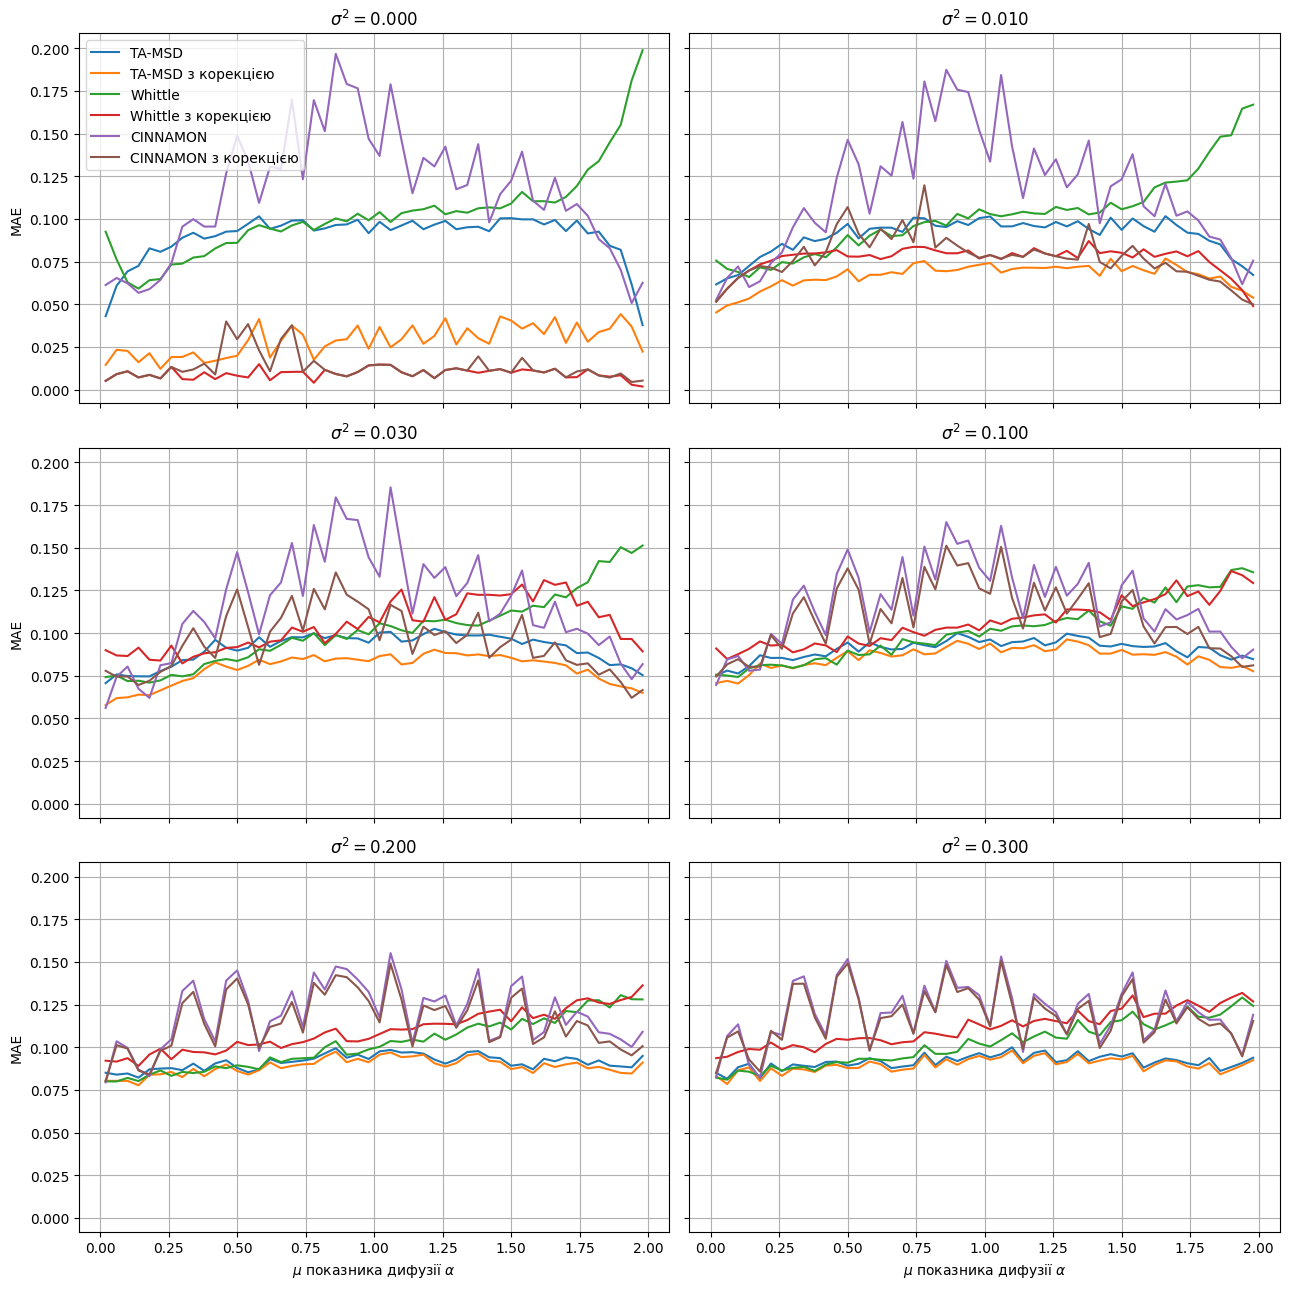

In [17]:
# ────────────────────── 1. Parameters ──────────────────────
HURST   = [i/100 for i in range(1, 100, 2)]          # 0.01 … 0.99
sigma   = [0, 0.01, 0.03, 0.1, 0.2, 0.3]          # 6 values of σ²
methods = ['TA-MSD', 'TA-MSD з корекцією', 'Whittle','Whittle з корекцією', 'CINNAMON', 'CINNAMON з корекцією' ]
# methods = ['TA-MSD', 'TA-MSD з корекцією', 'CINNAMON', 'CINNAMON з корекцією' ]

T, N    = 65, 100                                # trajectory length

TFalpha      = Tamsd(use_correction=False, is_increments=False)  # TA-MSD
# TFalphaTEA   = Tamsd(use_correction=True, is_increments=True)   # TA-MSD (correction)
models_class = models_phenom()

alphaTEA   = Tamsd(use_correction=False, is_increments=False, return_TEA=True)

examples = 8        # ← now you can set any positive number

# ────────────────────── 2. Error array ──────────────────────
errs = np.zeros((len(sigma), len(HURST), len(methods)))

# ────────────────────── 3. Trajectory generation and MAE calculation ──────────────────────
for h_ind, hurst in enumerate(HURST):
    print(f'H = {hurst:.2f}')
    for _ in range(examples):
        D = 10**(np.random.random() * 12 - 6)                 # random diffusion coefficient
        
        for k, s2 in enumerate(sigma):
            cumts, lab = models_class.single_state(
                N=N, T=T, Ds=[D, 0], alphas=[hurst * 2, s2]
            )
            ts  = (cumts[1:] - cumts[:-1]).transpose(1, 0, 2)  # displacements
            lab = lab[0, :, 0]                                 # true α values
            cumts = cumts.transpose(1, 2, 0)                   # [traj, dim, t]
            
            cumts = cumts.transpose(0, 2, 1)
            alphatea = alphaTEA(cumts)
            
            pred_25   = []            
            for tr in cumts:
                pred_25.append(alpha_estim_boost(tr))      # shape (N,)       
            pred_25 = np.array(pred_25)
            pred_25_cor = correct_alpha_cinnamon(pred_25, T, mu=alphatea)

            tamsd_pred = TFalpha(cumts) 
            tamsd_pred_cor = correct_alpha_tamsd(tamsd_pred, T, mu=alphatea)
            
            # ── MAE for the four methods ──────────────────────
            pred_whittle  = np.array([
                whittle(sp[:, 0]) + whittle(sp[:, 1]) 
                for sp in ts
            ])
            pred_whittle_cor = correct_alpha_whittle(pred_whittle, T, mu=alphatea)

            mae_whittle0    = np.mean(np.abs(pred_whittle - lab))
            mae_whittle    = np.mean(np.abs(pred_whittle_cor - lab))
            mae_cin    = np.mean(np.abs(pred_25 - lab))
            mae_cin_cor    = np.mean(np.abs(pred_25_cor - lab))
            mae_tf       = np.mean(np.abs(tamsd_pred - lab))
            mae_tf_tea   = np.mean(np.abs(tamsd_pred_cor - lab))
            
            # ⬇️ accumulate errors (NOTE: '+=')
            errs[k, h_ind, :] += [ mae_tf, mae_tf_tea, mae_whittle0, mae_whittle, mae_cin, mae_cin_cor]
            # errs[k, h_ind, :] += [ mae_tf, mae_tf_tea, mae_cin, mae_cin_cor]
# ⬇️ average over the number of runs
errs /= examples

# ────────────────────── 4. Plotting 6 graphs (3×2) ──────────────────────
cmap   = plt.cm.get_cmap('tab10')
colors = {m: cmap(i) for i, m in enumerate(methods)}

fig, axes = plt.subplots(3, 2, figsize=(13, 13), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (ax, s2) in enumerate(zip(axes, sigma)):
    for m in methods:
        m_idx = methods.index(m)
        ax.plot(
            np.array(HURST) * 2,
            errs[idx, :, m_idx],
            label=m if idx == 0 else None,
            color=colors[m]
        )
    
    ax.set_title(rf'$\sigma^2 = {s2:.3f}$')
    ax.grid(True)
    if idx % 2 == 0:
        ax.set_ylabel('MAE')
    if idx // 2 == 2:
        ax.set_xlabel(r'$\mu$ показника дифузії $\alpha$')

# display legend only once
axes[0].legend()
plt.tight_layout()
plt.show()
